# Sprite Feature Sensitivity Under Translation, Rotation, and Scale

This notebook measures how last-layer local features from a randomly initialized HARPL-style 5x5 Conv2d encoder change when each animal sprite is translated, rotated, scaled, and transformed by combinations of those actions.

The experiment has two parts:

- A vanilla random encoder matching the moving-animals HARPL encoder shape: six 5x5 conv layers, first two layers stride 2, 32 output channels, eval mode, full spatial features.
- A practical finite Sim(2) lifting/pooling wrapper around the same base encoder. This is not a new dependency and is meant as an executable first test of whether shared-weight scale-rotation lifting can reduce the measured artifacts. It approximates Sim(2) on sampled rotations and log-scales, then group-pools descriptors.

The measured quantities are feature drift relative to the centered, unrotated, unit-scale rendering of the same sprite. Translation is expected to produce spatial shifts in local feature maps; rotation and scale are not symmetries of an ordinary CNN and usually produce larger descriptor drift.

In [1]:
from pathlib import Path
import itertools
import sys
import math
import warnings

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
except Exception as exc:
    raise RuntimeError(
        "This notebook needs PyTorch. Run it in the same environment/kernel used for HARPL training."
    ) from exc

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SPRITE_DIR = PROJECT_ROOT / "datasets" / "animals"
SPRITE_PATHS = sorted(SPRITE_DIR.glob("sprite_*.png"), key=lambda p: int(p.stem.split("_")[1]))

assert SPRITE_PATHS, f"No sprite_*.png files found in {SPRITE_DIR}"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from harpl.networks.utils import setup_encoder
except Exception as exc:
    raise RuntimeError(
        f"Could not import HARPL from {PROJECT_ROOT}. Start Jupyter from the repo root or install the package editable."
    ) from exc

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

OUTPUT_SIZE = 64
BACKGROUND = 0.5
ENC_CHANNELS = 32
ENC_LAYERS = 6
ENC_KERNELS = [(5, 5)] * ENC_LAYERS
ENC_STRIDES = [(2, 2), (2, 2), (1, 1), (1, 1), (1, 1), (1, 1)]
ENC_PADDINGS = [(2, 2)] * ENC_LAYERS
ENC_POOL = None
USE_BN = True

# Keep this compact enough to run interactively. Increase these lists for denser sweeps.
TRANSLATIONS_PX = [(8, 0), (-8, 0), (0, 8), (8, -8)]
ROTATIONS_DEG = [30, 60, 90, 120, 180]
SCALES = [0.75, 1.25, 1.50]

CENTER = ((OUTPUT_SIZE - 1) / 2.0, (OUTPUT_SIZE - 1) / 2.0)

print(f"Project root: {PROJECT_ROOT}")
print(f"Found {len(SPRITE_PATHS)} sprites in {SPRITE_DIR}")
print(f"Device: {DEVICE}")

Project root: /Users/matushalak/Documents/harpl
Found 10 sprites in /Users/matushalak/Documents/harpl/datasets/animals
Device: cpu


## Rendering Helpers

The renderer loads RGBA sprites, transforms the sprite around its own center, places its center at a requested output-frame position, and alpha-composites the result onto the same gray background convention used by the moving-animal data generator. The encoder receives the composited RGB frame.

In [2]:
def sprite_idx(path: Path) -> int:
    return int(path.stem.split("_")[1])


def load_rgba_tensor(path: Path, device=DEVICE) -> torch.Tensor:
    arr = np.asarray(Image.open(path).convert("RGBA"), dtype=np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1).to(device=device, dtype=DTYPE)


def _pixel_grid(height: int, width: int, device=DEVICE) -> tuple[torch.Tensor, torch.Tensor]:
    ys, xs = torch.meshgrid(
        torch.arange(height, device=device, dtype=DTYPE),
        torch.arange(width, device=device, dtype=DTYPE),
        indexing="ij",
    )
    return xs, ys


def transform_rgba_sprite(
    rgba: torch.Tensor,
    position_xy: tuple[float, float] = CENTER,
    rotation_deg: float = 0.0,
    scale: float = 1.0,
    output_size: int = OUTPUT_SIZE,
) -> torch.Tensor:
    """Return transformed sprite RGBA as [4, output_size, output_size]."""
    assert rgba.ndim == 3 and rgba.shape[0] == 4
    src_h, src_w = rgba.shape[-2:]
    out_h = out_w = output_size
    xs, ys = _pixel_grid(out_h, out_w, device=rgba.device)

    cx = (src_w - 1) / 2.0
    cy = (src_h - 1) / 2.0
    tx, ty = position_xy

    theta = math.radians(rotation_deg)
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)

    # Inverse map output pixels into source sprite coordinates.
    dx = (xs - tx) / scale
    dy = (ys - ty) / scale
    src_x = cos_t * dx + sin_t * dy + cx
    src_y = -sin_t * dx + cos_t * dy + cy

    if src_w > 1:
        grid_x = 2.0 * src_x / (src_w - 1) - 1.0
    else:
        grid_x = torch.zeros_like(src_x)
    if src_h > 1:
        grid_y = 2.0 * src_y / (src_h - 1) - 1.0
    else:
        grid_y = torch.zeros_like(src_y)

    grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)
    sampled = F.grid_sample(
        rgba.unsqueeze(0),
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=True,
    )[0]
    return sampled.clamp(0.0, 1.0)


def composite_rgba_on_gray(rgba_frame: torch.Tensor, background: float = BACKGROUND) -> torch.Tensor:
    rgb = rgba_frame[:3]
    alpha = rgba_frame[3:4]
    return alpha * rgb + (1.0 - alpha) * background


def render_sprite_rgb(
    rgba: torch.Tensor,
    translation_px: tuple[float, float] = (0.0, 0.0),
    rotation_deg: float = 0.0,
    scale: float = 1.0,
    output_size: int = OUTPUT_SIZE,
) -> torch.Tensor:
    x = CENTER[0] + float(translation_px[0])
    y = CENTER[1] + float(translation_px[1])
    rgba_frame = transform_rgba_sprite(rgba, (x, y), rotation_deg, scale, output_size)
    return composite_rgba_on_gray(rgba_frame)


def show_rgb_grid(images: list[torch.Tensor], titles: list[str], ncols: int = 5, figsize=(12, 5)):
    nrows = math.ceil(len(images) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, img, title in zip(axes.ravel(), images, titles):
        ax.imshow(img.detach().cpu().permute(1, 2, 0).numpy().clip(0, 1))
        ax.set_title(title, fontsize=9)
    plt.tight_layout()
    return fig

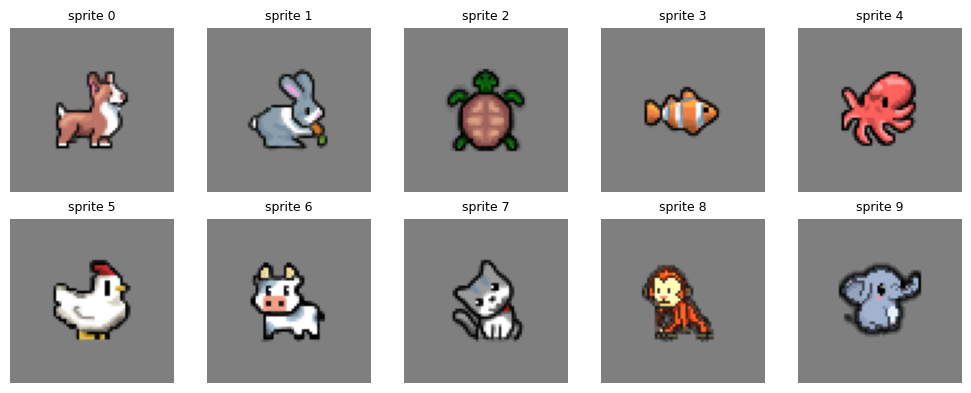

In [3]:
sprite_rgba = {sprite_idx(path): load_rgba_tensor(path) for path in SPRITE_PATHS}
preview_ids = sorted(sprite_rgba)[:10]
preview_images = [render_sprite_rgb(sprite_rgba[i]) for i in preview_ids]
show_rgb_grid(preview_images, [f"sprite {i}" for i in preview_ids], ncols=5, figsize=(10, 4));

## Transformation Families

Each family is evaluated for every sprite. The baseline is always the same sprite at center, zero rotation, unit scale. The grids below avoid identity values inside each transformation family so each row represents a nontrivial perturbation.

In [4]:
def transformation_grid() -> pd.DataFrame:
    rows = []

    def add(family, translation=(0, 0), rotation=0, scale=1.0):
        rows.append({
            "family": family,
            "dx": float(translation[0]),
            "dy": float(translation[1]),
            "rotation_deg": float(rotation),
            "scale": float(scale),
        })

    for t in TRANSLATIONS_PX:
        add("translate", t, 0, 1.0)
    for t, r in itertools.product(TRANSLATIONS_PX, ROTATIONS_DEG):
        add("translate_rotate", t, r, 1.0)
    for t, s in itertools.product(TRANSLATIONS_PX, SCALES):
        add("translate_scale", t, 0, s)
    for s, r in itertools.product(SCALES, ROTATIONS_DEG):
        add("scale_rotate", (0, 0), r, s)
    for t, s, r in itertools.product(TRANSLATIONS_PX, SCALES, ROTATIONS_DEG):
        add("translate_scale_rotate", t, r, s)
    for r in ROTATIONS_DEG:
        add("rotate", (0, 0), r, 1.0)
    for s in SCALES:
        add("scale", (0, 0), 0, s)

    return pd.DataFrame(rows)

transforms_df = transformation_grid()
display(transforms_df.groupby("family").size().rename("n_conditions").reset_index())
display(transforms_df.head())

,family,n_conditions
0,rotate,5
1,scale,3
2,scale_rotate,15
3,translate,4
4,translate_rotate,20
5,translate_scale,12
6,translate_scale_rotate,60


,family,dx,dy,rotation_deg,scale
0,translate,8.0,0.0,0.0,1.0
1,translate,-8.0,0.0,0.0,1.0
2,translate,0.0,8.0,0.0,1.0
3,translate,8.0,-8.0,0.0,1.0
4,translate_rotate,8.0,0.0,30.0,1.0


## Random HARPL-Style Encoder

This instantiates the encoder in eval mode with random weights. We keep `return_full_features=True`, so the last layer returns a local feature map instead of spatially averaged features.

In [5]:
def make_harpl_random_encoder(seed: int = SEED) -> nn.Module:
    torch.manual_seed(seed)
    encoder = setup_encoder(
        kind="conv2d",
        input_size=OUTPUT_SIZE,
        n_in_channels=3,
        latent_size=ENC_CHANNELS,
        use_bn=USE_BN,
        enc_n_layers=ENC_LAYERS,
        enc_kernel_size=ENC_KERNELS,
        enc_stride=ENC_STRIDES,
        enc_padding=ENC_PADDINGS,
        enc_pool_size=ENC_POOL,
        return_full_features=True,
        is_frozen=False,
    ).to(DEVICE)
    encoder.eval()
    return encoder


encoder = make_harpl_random_encoder()
with torch.no_grad():
    example = torch.stack([render_sprite_rgb(sprite_rgba[preview_ids[0]])]).to(DEVICE)
    feature_map = encoder(example)

print(encoder)
print(f"Example input: {tuple(example.shape)} -> last-layer feature map: {tuple(feature_map.shape)}")

Conv2dEncoder(
  (backbone): Sequential(
    (conv0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (batchNorm0): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU()
    (conv1): Conv2d(32, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (batchNorm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu1): ReLU()
    (conv2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (batchNorm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu2): ReLU()
    (conv3): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (batchNorm3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu3): ReLU()
    (conv4): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (batchNorm4): BatchNorm2d(32, eps=1e-05, mome

## Feature Drift Metrics

For each transformed frame, the notebook records:

- `map_rel_l2`: normalized L2 drift of the full local feature map at fixed feature coordinates.
- `pooled_rel_l2`: normalized L2 drift of the spatially averaged last-layer descriptor.
- `pooled_cosine_distance`: cosine distance of the spatially averaged descriptor.
- `best_shift_map_rel_l2`: normalized feature-map drift after allowing a small integer spatial shift in the final feature map. This separates true descriptor changes from the expected shift induced by translation.

In [6]:
def rel_l2(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return torch.linalg.vector_norm(a - b) / (torch.linalg.vector_norm(b) + eps)


def cosine_distance(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    a_flat = a.flatten()
    b_flat = b.flatten()
    sim = torch.dot(a_flat, b_flat) / ((torch.linalg.vector_norm(a_flat) + eps) * (torch.linalg.vector_norm(b_flat) + eps))
    return 1.0 - sim


def shifted_overlap(a: torch.Tensor, b: torch.Tensor, shift_y: int, shift_x: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Return overlapping C,H,W crops after shifting a relative to b."""
    _, h, w = a.shape
    if shift_y >= 0:
        a_y = slice(shift_y, h)
        b_y = slice(0, h - shift_y)
    else:
        a_y = slice(0, h + shift_y)
        b_y = slice(-shift_y, h)
    if shift_x >= 0:
        a_x = slice(shift_x, w)
        b_x = slice(0, w - shift_x)
    else:
        a_x = slice(0, w + shift_x)
        b_x = slice(-shift_x, w)
    return a[:, a_y, a_x], b[:, b_y, b_x]


def best_shifted_rel_l2(a: torch.Tensor, b: torch.Tensor, max_shift: int = 5) -> tuple[float, tuple[int, int]]:
    best = None
    best_shift = (0, 0)
    for sy in range(-max_shift, max_shift + 1):
        for sx in range(-max_shift, max_shift + 1):
            aa, bb = shifted_overlap(a, b, sy, sx)
            if aa.numel() == 0:
                continue
            value = rel_l2(aa, bb).item()
            if best is None or value < best:
                best = value
                best_shift = (sy, sx)
    return float(best), best_shift


def encode_batch(encoder: nn.Module, images: torch.Tensor, batch_size: int = 128) -> torch.Tensor:
    features = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            features.append(encoder(images[start:start + batch_size].to(DEVICE)).detach().cpu())
    return torch.cat(features, dim=0)

In [7]:
def run_vanilla_feature_sweep(encoder: nn.Module, batch_size: int = 128) -> pd.DataFrame:
    records = []
    all_sprite_ids = sorted(sprite_rgba)

    for sid in all_sprite_ids:
        rgba = sprite_rgba[sid]
        baseline_img = render_sprite_rgb(rgba)
        baseline_feat = encode_batch(encoder, baseline_img.unsqueeze(0), batch_size=batch_size)[0]
        baseline_desc = baseline_feat.mean(dim=(-2, -1))

        frames = []
        row_specs = []
        for row in transforms_df.itertuples(index=False):
            frame = render_sprite_rgb(
                rgba,
                translation_px=(row.dx, row.dy),
                rotation_deg=row.rotation_deg,
                scale=row.scale,
            )
            frames.append(frame)
            row_specs.append(row)

        feats = encode_batch(encoder, torch.stack(frames), batch_size=batch_size)

        for spec, feat in zip(row_specs, feats):
            desc = feat.mean(dim=(-2, -1))
            shifted_value, best_shift = best_shifted_rel_l2(feat, baseline_feat)
            records.append({
                "sprite": sid,
                "family": spec.family,
                "dx": spec.dx,
                "dy": spec.dy,
                "rotation_deg": spec.rotation_deg,
                "scale": spec.scale,
                "map_rel_l2": rel_l2(feat, baseline_feat).item(),
                "best_shift_map_rel_l2": shifted_value,
                "best_shift_y": best_shift[0],
                "best_shift_x": best_shift[1],
                "pooled_rel_l2": rel_l2(desc, baseline_desc).item(),
                "pooled_cosine_distance": cosine_distance(desc, baseline_desc).item(),
            })

    return pd.DataFrame.from_records(records)


vanilla_df = run_vanilla_feature_sweep(encoder)
display(vanilla_df.head())
print(f"Rows: {len(vanilla_df):,}")

,sprite,family,dx,dy,rotation_deg,scale,map_rel_l2,best_shift_map_rel_l2,best_shift_y,best_shift_x,pooled_rel_l2,pooled_cosine_distance
0,0,translate,8.0,0.0,0.0,1.0,0.023477,0.023477,0,0,0.000513,1.192093e-07
1,0,translate,-8.0,0.0,0.0,1.0,0.023550,0.023550,0,0,0.000417,1.192093e-07
2,0,translate,0.0,8.0,0.0,1.0,0.022942,0.022942,0,0,0.001184,5.364418e-07
3,0,translate,8.0,-8.0,0.0,1.0,0.024301,0.024301,0,0,0.000664,2.980232e-07
4,0,translate_rotate,8.0,0.0,30.0,1.0,0.021650,0.021650,0,0,0.001588,1.251698e-06


Rows: 1,190


In [8]:
summary = (
    vanilla_df
    .groupby(["family", "sprite"])[["map_rel_l2", "best_shift_map_rel_l2", "pooled_rel_l2", "pooled_cosine_distance"]]
    .mean()
    .reset_index()
)
family_summary = (
    summary
    .groupby("family")[["map_rel_l2", "best_shift_map_rel_l2", "pooled_rel_l2", "pooled_cosine_distance"]]
    .agg(["mean", "std"])
)
display(family_summary)

pivot = summary.pivot(index="sprite", columns="family", values="pooled_rel_l2")
display(pivot)

map_rel_l2           best_shift_map_rel_l2           pooled_rel_l2           pooled_cosine_distance              
                             mean       std                  mean       std          mean       std                   mean           std
family                                                                                                                                  
rotate                   0.022909  0.003368              0.022909  0.003368      0.001204  0.000304           8.535385e-07  3.720484e-07
scale                    0.022417  0.003611              0.022417  0.003611      0.001785  0.000607           1.754363e-06  1.276387e-06
scale_rotate             0.024465  0.003447              0.024465  0.003447      0.001863  0.000598           1.841784e-06  1.099732e-06
translate                0.025171  0.003418              0.025171  0.003418      0.000821  0.000210           4.708767e-07  1.885126e-07
translate_rotate         0.024390  0.003423              0.024390  0.003423      0.001420  0.000273           1.112223e-06  4.208095e-07
translate_scale          0.024700  0.003417              0.024700  0.003417      0.001806  0.000533           1.744926e-06  1.038403e-06
translate_scale_rotate   0.024945  0.003301              0.024945  0.003301      0.001867  0.000554           1.842578e-06  1.059016e-06

family,rotate,scale,scale_rotate,translate,translate_rotate,translate_scale,translate_scale_rotate
sprite,,,,,,,
0,0.001371,0.001380,0.001554,0.000695,0.001412,0.001622,0.001542
1,0.001598,0.001533,0.001423,0.000643,0.001705,0.001450,0.001443
2,0.000709,0.001914,0.002172,0.001041,0.001089,0.001915,0.002014
3,0.000994,0.001153,0.001372,0.000539,0.001120,0.001136,0.001352
4,0.001047,0.002176,0.002270,0.001130,0.001590,0.002172,0.002310
5,0.001557,0.003222,0.003082,0.001004,0.001764,0.002989,0.002948
6,0.001196,0.001918,0.001678,0.000812,0.001289,0.001774,0.001711
7,0.001218,0.001473,0.001435,0.000673,0.001407,0.001650,0.001525
8,0.001497,0.001873,0.002426,0.001022,0.001748,0.002090,0.002498


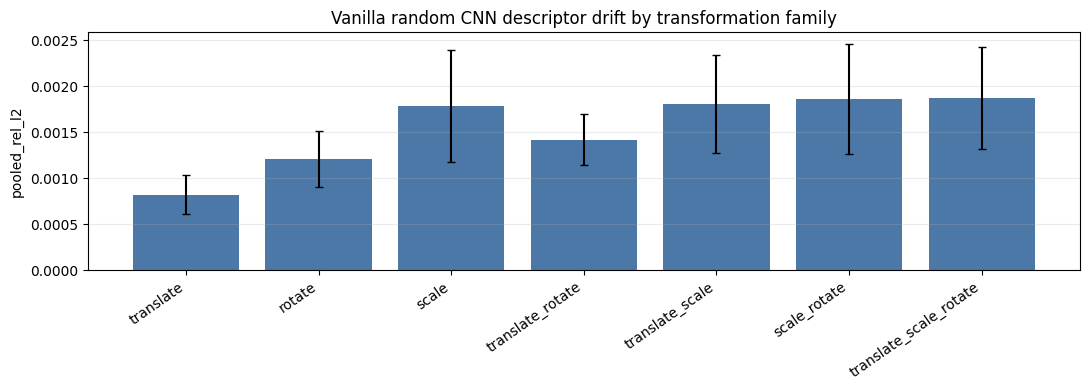

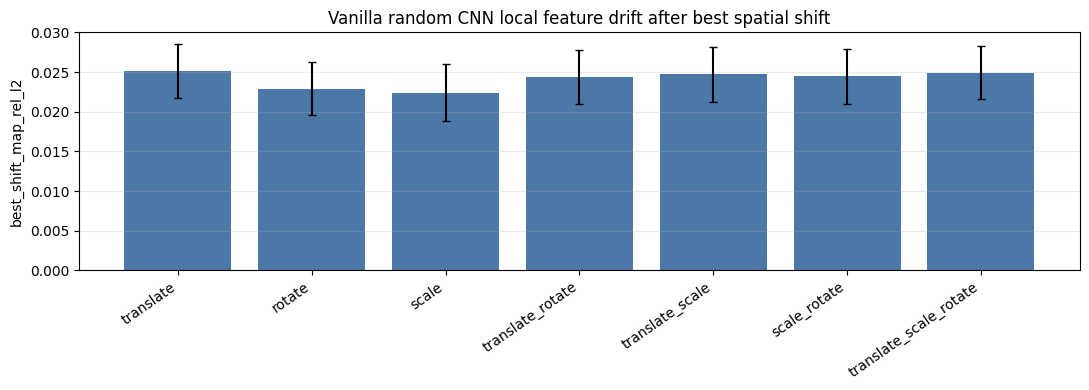

In [9]:
def plot_family_bars(df: pd.DataFrame, metric: str, title: str):
    order = [
        "translate", "rotate", "scale", "translate_rotate",
        "translate_scale", "scale_rotate", "translate_scale_rotate",
    ]
    data = df.groupby(["family", "sprite"])[metric].mean().reset_index()
    fig, ax = plt.subplots(figsize=(11, 4))
    positions = np.arange(len(order))
    means = [data.loc[data.family == fam, metric].mean() for fam in order]
    stds = [data.loc[data.family == fam, metric].std() for fam in order]
    ax.bar(positions, means, yerr=stds, capsize=3, color="#4C78A8")
    ax.set_xticks(positions)
    ax.set_xticklabels(order, rotation=35, ha="right")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    return fig

plot_family_bars(vanilla_df, "pooled_rel_l2", "Vanilla random CNN descriptor drift by transformation family");
plot_family_bars(vanilla_df, "best_shift_map_rel_l2", "Vanilla random CNN local feature drift after best spatial shift");

## Inspect One Sprite and One Feature Channel

The next cell visualizes the input perturbations and one high-energy channel from the last feature layer for a selected sprite. Change `SELECTED_SPRITE` and `SELECTED_CHANNEL` to inspect individual cases.

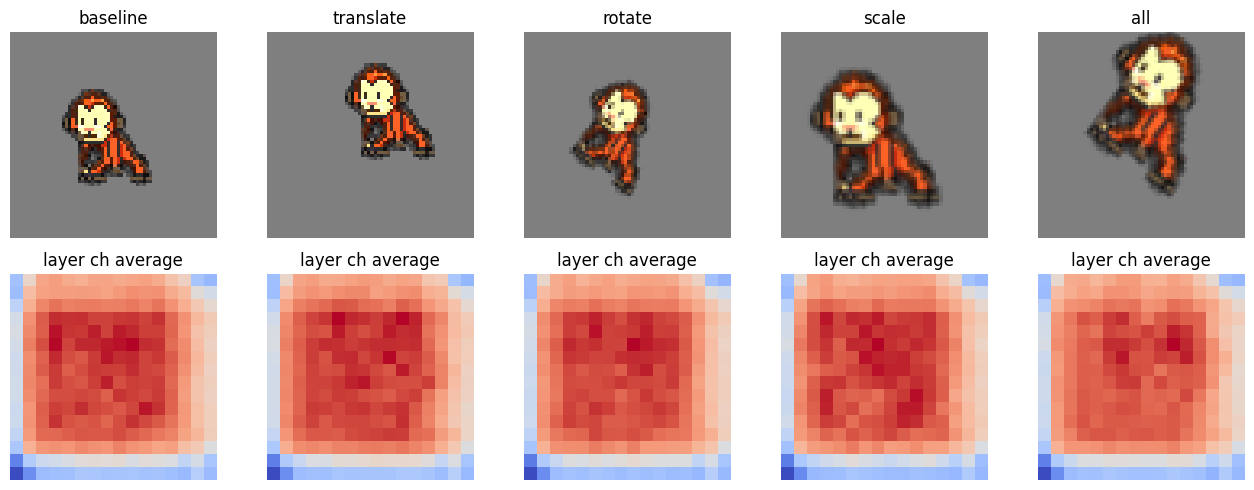

In [17]:
SELECTED_SPRITE = 8 if 8 in sprite_rgba else sorted(sprite_rgba)[0]
SELECTED_CHANNEL = None
VIS_ROWS = [
    {"name": "baseline", "translation": (0, 0), "rotation": 0, "scale": 1.0},
    {"name": "translate", "translation": (8, -8), "rotation": 0, "scale": 1.0},
    {"name": "rotate", "translation": (0, 0), "rotation": 37, "scale": 1.0},
    {"name": "scale", "translation": (0, 0), "rotation": 0, "scale": 1.43},
    {"name": "all", "translation": (8, -8), "rotation": 37, "scale": 1.43},
]

rgba = sprite_rgba[SELECTED_SPRITE]
vis_images = [
    render_sprite_rgb(rgba, row["translation"], row["rotation"], row["scale"])
    for row in VIS_ROWS
]
vis_feats = encode_batch(encoder, torch.stack(vis_images))

if SELECTED_CHANNEL is None:
    channel_energy = vis_feats[0].square().mean(dim=(-1, -2))
    SELECTED_CHANNEL = int(channel_energy.argmax())

fig, axes = plt.subplots(2, len(VIS_ROWS), figsize=(13, 5), squeeze=False)
for col, (row, img, feat) in enumerate(zip(VIS_ROWS, vis_images, vis_feats)):
    axes[0, col].imshow(img.detach().cpu().permute(1, 2, 0).numpy().clip(0, 1))
    axes[0, col].set_title(row["name"])
    axes[0, col].axis("off")

    fmap = feat.mean(dim=0).detach().cpu().numpy()
    im = axes[1, col].imshow(fmap, cmap="coolwarm")
    axes[1, col].set_title(f"layer ch average")
    axes[1, col].axis("off")

plt.tight_layout()

## Finite Sim(2) Lifting and Pooling Encoder

A full continuous Sim(2)-equivariant steerable encoder is a larger architectural change than swapping one PyTorch layer. As an executable first test, this notebook uses finite Sim(2) lifting:

1. Apply a shared base encoder to multiple inverse-transformed copies of the same input frame.
2. Treat the resulting stack as features over a sampled rotation x log-scale group grid.
3. Pool over the sampled group to produce an approximately scale-rotation-invariant descriptor.

This directly tests the practical question: does explicit shared-weight scale-rotation pooling reduce the measured descriptor artifacts for these sprites? It should mainly help rotation/scale families. It is not expected to fix all translation effects by itself; translation is measured separately through spatial feature shifts and global spatial pooling.

In [11]:
SIM2_ROTATIONS_DEG = list(range(0, 360, 45))
SIM2_SCALE_STEP = 1.25
SIM2_SCALE_EXPONENTS = [-2, -1, 0, 1, 2]
SIM2_SCALES = [SIM2_SCALE_STEP ** k for k in SIM2_SCALE_EXPONENTS]


def transform_rgb_frame_about_center(
    images: torch.Tensor,
    rotation_deg: float = 0.0,
    scale: float = 1.0,
    background: float = BACKGROUND,
) -> torch.Tensor:
    """Transform [B,3,H,W] frames about the output-frame center using bilinear sampling."""
    if images.ndim == 3:
        images = images.unsqueeze(0)
    b, c, h, w = images.shape
    xs, ys = _pixel_grid(h, w, device=images.device)
    cx = (w - 1) / 2.0
    cy = (h - 1) / 2.0

    theta = math.radians(rotation_deg)
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)

    dx = (xs - cx) / scale
    dy = (ys - cy) / scale
    src_x = cos_t * dx + sin_t * dy + cx
    src_y = -sin_t * dx + cos_t * dy + cy
    grid_x = 2.0 * src_x / (w - 1) - 1.0
    grid_y = 2.0 * src_y / (h - 1) - 1.0
    grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0).repeat(b, 1, 1, 1)

    sampled = F.grid_sample(
        images,
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=True,
    )

    # Replace out-of-frame zero padding with the known gray background.
    valid = (grid[..., 0].abs() <= 1.0) & (grid[..., 1].abs() <= 1.0)
    valid = valid[:, None].to(images.dtype)
    return sampled * valid + background * (1.0 - valid)


class FiniteSim2PooledEncoder(nn.Module):
    def __init__(
        self,
        base_encoder: nn.Module,
        rotations_deg: list[int] = SIM2_ROTATIONS_DEG,
        scales: list[float] = SIM2_SCALES,
        pool: str = "mean",
    ):
        super().__init__()
        self.base_encoder = base_encoder
        self.rotations_deg = list(rotations_deg)
        self.scales = list(scales)
        self.pool = pool

    def lift_descriptors(self, x: torch.Tensor, batch_size: int = 64) -> torch.Tensor:
        """Return [B, n_scales, n_rotations, C] group-lifted spatially pooled descriptors."""
        descs = []
        with torch.no_grad():
            for scale in self.scales:
                scale_descs = []
                for angle in self.rotations_deg:
                    # Inverse transform canonicalizes this sampled group element before shared encoding.
                    xt = transform_rgb_frame_about_center(x, rotation_deg=-angle, scale=1.0 / scale)
                    fmaps = []
                    for start in range(0, len(xt), batch_size):
                        fmap = self.base_encoder(xt[start:start + batch_size].to(DEVICE))
                        fmaps.append(fmap.mean(dim=(-2, -1)).detach().cpu())
                    scale_descs.append(torch.cat(fmaps, dim=0))
                descs.append(torch.stack(scale_descs, dim=1))
        return torch.stack(descs, dim=1)

    def forward(self, x: torch.Tensor, batch_size: int = 64) -> torch.Tensor:
        lifted = self.lift_descriptors(x, batch_size=batch_size)
        if self.pool == "mean":
            return lifted.mean(dim=(1, 2))
        if self.pool == "max":
            return lifted.amax(dim=(1, 2))
        raise ValueError(f"Unsupported pool={self.pool!r}")


sim2_encoder = FiniteSim2PooledEncoder(encoder, pool="mean")
print(f"Sim2 grid: {len(SIM2_SCALES)} scales x {len(SIM2_ROTATIONS_DEG)} rotations = {len(SIM2_SCALES) * len(SIM2_ROTATIONS_DEG)} shared encodes per image")

Sim2 grid: 5 scales x 8 rotations = 40 shared encodes per image


In [12]:
def run_sim2_descriptor_sweep(sim2_encoder: FiniteSim2PooledEncoder, batch_size: int = 64) -> pd.DataFrame:
    records = []
    for sid in sorted(sprite_rgba):
        rgba = sprite_rgba[sid]
        baseline_img = render_sprite_rgb(rgba).unsqueeze(0)
        baseline_desc = sim2_encoder(baseline_img.to(DEVICE), batch_size=batch_size)[0]

        frames = []
        specs = []
        for row in transforms_df.itertuples(index=False):
            frames.append(render_sprite_rgb(
                rgba,
                translation_px=(row.dx, row.dy),
                rotation_deg=row.rotation_deg,
                scale=row.scale,
            ))
            specs.append(row)

        images = torch.stack(frames).to(DEVICE)
        descs = []
        for start in range(0, len(images), batch_size):
            descs.append(sim2_encoder(images[start:start + batch_size], batch_size=batch_size))
        descs = torch.cat(descs, dim=0)

        for spec, desc in zip(specs, descs):
            records.append({
                "sprite": sid,
                "family": spec.family,
                "dx": spec.dx,
                "dy": spec.dy,
                "rotation_deg": spec.rotation_deg,
                "scale": spec.scale,
                "sim2_pooled_rel_l2": rel_l2(desc, baseline_desc).item(),
                "sim2_pooled_cosine_distance": cosine_distance(desc, baseline_desc).item(),
            })
    return pd.DataFrame.from_records(records)


sim2_df = run_sim2_descriptor_sweep(sim2_encoder)
display(sim2_df.head())
print(f"Rows: {len(sim2_df):,}")

,sprite,family,dx,dy,rotation_deg,scale,sim2_pooled_rel_l2,sim2_pooled_cosine_distance
0,0,translate,8.0,0.0,0.0,1.0,0.000304,1.192093e-07
1,0,translate,-8.0,0.0,0.0,1.0,0.000294,2.384186e-07
2,0,translate,0.0,8.0,0.0,1.0,0.000389,2.384186e-07
3,0,translate,8.0,-8.0,0.0,1.0,0.000398,2.384186e-07
4,0,translate_rotate,8.0,0.0,30.0,1.0,0.000505,2.384186e-07


Rows: 1,190


In [13]:
comparison_df = vanilla_df.merge(
    sim2_df,
    on=["sprite", "family", "dx", "dy", "rotation_deg", "scale"],
    how="inner",
)
comparison_df["rel_l2_reduction"] = comparison_df["pooled_rel_l2"] - comparison_df["sim2_pooled_rel_l2"]
comparison_df["relative_reduction_fraction"] = comparison_df["rel_l2_reduction"] / comparison_df["pooled_rel_l2"].clip(lower=1e-8)

comparison_summary = (
    comparison_df
    .groupby("family")[["pooled_rel_l2", "sim2_pooled_rel_l2", "rel_l2_reduction", "relative_reduction_fraction"]]
    .agg(["mean", "std"])
)
display(comparison_summary)

sprite_comparison = (
    comparison_df
    .groupby(["sprite", "family"])[["pooled_rel_l2", "sim2_pooled_rel_l2", "relative_reduction_fraction"]]
    .mean()
    .reset_index()
)
display(sprite_comparison.pivot(index="sprite", columns="family", values="relative_reduction_fraction"))

pooled_rel_l2           sim2_pooled_rel_l2           rel_l2_reduction           relative_reduction_fraction          
                                mean       std               mean       std             mean       std                        mean       std
family                                                                                                                                      
rotate                      0.001204  0.000407           0.000183  0.000162         0.001021  0.000449                    0.827062  0.170323
scale                       0.001785  0.000821           0.001309  0.000888         0.000476  0.000371                    0.292164  0.232863
scale_rotate                0.001863  0.000811           0.001317  0.000882         0.000546  0.000442                    0.318801  0.243346
translate                   0.000821  0.000321           0.000445  0.000185         0.000376  0.000248                    0.431659  0.190569
translate_rotate            0.001420  0.000435           0.000519  0.000204         0.000901  0.000457                    0.603035  0.186006
translate_scale             0.001806  0.000744           0.001149  0.000721         0.000657  0.000467                    0.371915  0.241494
translate_scale_rotate      0.001867  0.000753           0.001171  0.000751         0.000696  0.000513                    0.385713  0.252990

family,rotate,scale,scale_rotate,translate,translate_rotate,translate_scale,translate_scale_rotate
sprite,,,,,,,
0,0.889107,0.254715,0.343372,0.443717,0.682706,0.459269,0.409868
1,0.891737,0.601163,0.560944,0.568306,0.793231,0.580676,0.599120
2,0.807156,0.181573,0.250019,0.226701,0.353200,0.301662,0.310261
3,0.882189,0.160967,0.273614,0.320257,0.579497,0.226776,0.349777
4,0.669438,0.074696,0.120418,0.431505,0.514239,0.230528,0.284268
5,0.870300,0.099363,0.054581,0.437250,0.629426,0.194691,0.152956
6,0.790826,0.266466,0.170419,0.498081,0.563601,0.331509,0.258714
7,0.810415,0.639435,0.646082,0.398766,0.639871,0.599945,0.613347
8,0.877373,0.286378,0.426358,0.554313,0.719330,0.397638,0.445247


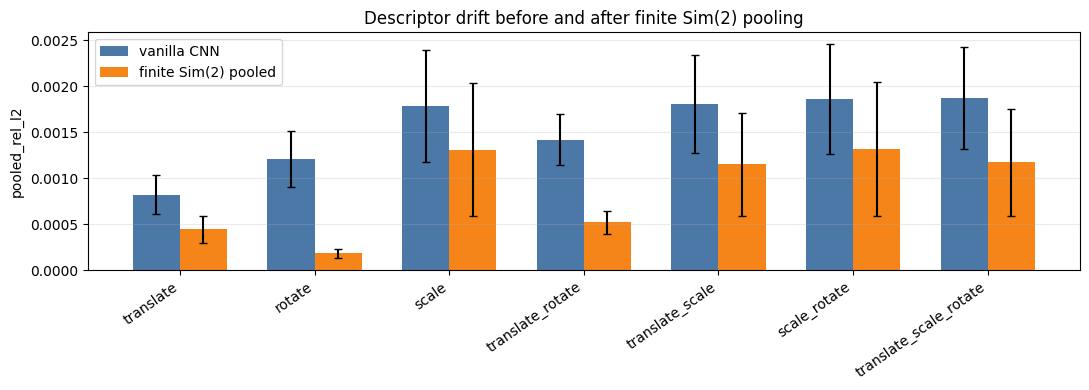

In [14]:
order = [
    "translate", "rotate", "scale", "translate_rotate",
    "translate_scale", "scale_rotate", "translate_scale_rotate",
]
plot_data = comparison_df.groupby(["family", "sprite"])[["pooled_rel_l2", "sim2_pooled_rel_l2"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(order))
width = 0.35
vanilla_means = [plot_data.loc[plot_data.family == fam, "pooled_rel_l2"].mean() for fam in order]
sim2_means = [plot_data.loc[plot_data.family == fam, "sim2_pooled_rel_l2"].mean() for fam in order]
vanilla_stds = [plot_data.loc[plot_data.family == fam, "pooled_rel_l2"].std() for fam in order]
sim2_stds = [plot_data.loc[plot_data.family == fam, "sim2_pooled_rel_l2"].std() for fam in order]

ax.bar(x - width / 2, vanilla_means, width, yerr=vanilla_stds, capsize=3, label="vanilla CNN", color="#4C78A8")
ax.bar(x + width / 2, sim2_means, width, yerr=sim2_stds, capsize=3, label="finite Sim(2) pooled", color="#F58518")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=35, ha="right")
ax.set_ylabel("pooled_rel_l2")
ax.set_title("Descriptor drift before and after finite Sim(2) pooling")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()

## Optional: Check Rotation Equivariance with ESCNN

If `escnn` is installed in the active kernel, the following cell builds a small C8 rotation-equivariant encoder. This is useful as a rotation-only sanity check, but it does not replace the finite Sim(2) scale-rotation lifting above: the public `escnn.gspaces.rot2dOnR2` path constrains kernels for rotations/reflections of the plane, not continuous scale transformations.

In [ ]:
try:
    from escnn import gspaces
    from escnn import nn as enn
except Exception as exc:
    gspaces = None
    enn = None
    warnings.warn(f"escnn is not available in this kernel; skipping optional rotation-equivariant encoder: {exc}")


class ESCNNRotationEncoder(nn.Module):
    def __init__(self, channels: int = 16, n_rotations: int = 8):
        super().__init__()
        if gspaces is None or enn is None:
            raise RuntimeError("escnn is not installed")
        self.r2_act = gspaces.rot2dOnR2(N=n_rotations)
        in_type = enn.FieldType(self.r2_act, 3 * [self.r2_act.trivial_repr])
        hid_type = enn.FieldType(self.r2_act, channels * [self.r2_act.regular_repr])
        self.in_type = in_type
        self.net = enn.SequentialModule(
            enn.R2Conv(in_type, hid_type, kernel_size=5, padding=2, stride=2, bias=False),
            enn.InnerBatchNorm(hid_type),
            enn.ReLU(hid_type, inplace=True),
            enn.R2Conv(hid_type, hid_type, kernel_size=5, padding=2, stride=2, bias=False),
            enn.InnerBatchNorm(hid_type),
            enn.ReLU(hid_type, inplace=True),
            enn.R2Conv(hid_type, hid_type, kernel_size=5, padding=2, stride=1, bias=False),
            enn.InnerBatchNorm(hid_type),
            enn.ReLU(hid_type, inplace=True),
            enn.GroupPooling(hid_type),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gx = enn.GeometricTensor(x, self.in_type)
        y = self.net(gx).tensor
        return y.mean(dim=(-2, -1))


if gspaces is not None and enn is not None:
    torch.manual_seed(SEED)
    escnn_encoder = ESCNNRotationEncoder().to(DEVICE).eval()
    print(escnn_encoder)
else:
    escnn_encoder = None

## Reading The Results

Use the `family_summary`, `pivot`, and `comparison_summary` tables as the main quantitative outputs.

Expected patterns:

- Translation should have relatively lower `best_shift_map_rel_l2` than raw `map_rel_l2` if the CNN mostly shifts local features as expected.
- Rotation and scale should usually increase vanilla `pooled_rel_l2`, because ordinary 5x5 conv kernels are not rotation- or scale-equivariant.
- Finite Sim(2) pooling should reduce descriptor drift most clearly for `rotate`, `scale`, and `scale_rotate`. If it also reduces mixed families, the remaining error is likely dominated by interpolation, finite sampling, border effects, and translation/object-centering.
- Sprite-specific outliers are the rows/columns to inspect next. Compare them to alpha-mask hardness and render artifacts from `sprite_8_9_low_level_analysis.ipynb`.

For a stricter Sim(2) encoder experiment after this notebook, replace the finite input-lift wrapper with a trainable scale-rotation group convolution implementation and repeat the same metric table. The metric code here is written so the encoder comparison only needs to return a descriptor per frame.